In [1]:
import os
import cv2
import numpy as np

def load_images_labels(data_dir, image_size=(64, 64)):
    images = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
    print("Class mapping:", class_to_idx)
    for cls in class_names:
        cls_folder = os.path.join(data_dir, cls)
        for file in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, image_size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(img)
            labels.append(class_to_idx[cls])
    images = np.array(images)
    labels = np.array(labels)
    print("Total images loaded:", len(images))
    return images, labels, class_names

data_folder = r'C:\Users\Lenovo\Downloads\satellite\data'
images, labels, class_names = load_images_labels(data_folder)

Class mapping: {'cloudy': 0, 'desert': 1, 'green_area': 2, 'water': 3}
Total images loaded: 5631


In [2]:
from skimage.feature import hog

def extract_hog_features(images):
    hog_features = []
    for idx, img in enumerate(images):
        feature = hog(img, pixels_per_cell=(16, 16), cells_per_block=(2, 2), block_norm='L2-Hys')
        hog_features.append(feature)
        if idx == 0:
            print("Sample HOG feature length:", len(feature))
    print("Total images processed:", len(images))
    return hog_features

hog_features = extract_hog_features(images)

Sample HOG feature length: 324
Total images processed: 5631


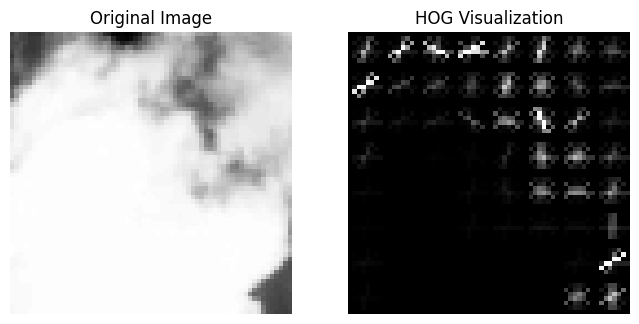

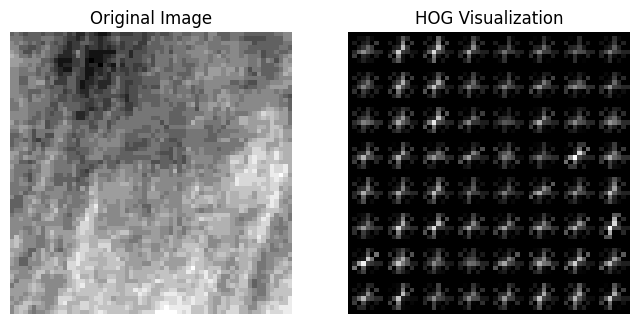

In [4]:
from skimage import exposure
import matplotlib.pyplot as plt
def visualize_hog(images, num_samples=2):
    for i in range(num_samples):
        img = images[i]
        features, hog_image = hog(img,
                                  orientations=9,
                                  pixels_per_cell=(8, 8),
                                  cells_per_block=(2, 2),
                                  block_norm='L2-Hys',
                                  visualize=True)
        hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

        plt.figure(figsize=(8,4))
        plt.subplot(1, 2, 1)
        plt.title('Original Image')
        plt.axis('off')
        plt.imshow(img, cmap='gray')

        plt.subplot(1, 2, 2)
        plt.title('HOG Visualization')
        plt.axis('off')
        plt.imshow(hog_image_rescaled, cmap='gray')

        plt.show()


visualize_hog(images, num_samples=2)

SVM Accuracy: 69.57 %

SVM Classification Report:
               precision    recall  f1-score   support

      cloudy       0.59      0.55      0.57       300
      desert       0.59      0.59      0.59       227
  green_area       0.78      0.79      0.78       300
       water       0.78      0.83      0.81       300

    accuracy                           0.70      1127
   macro avg       0.69      0.69      0.69      1127
weighted avg       0.69      0.70      0.69      1127



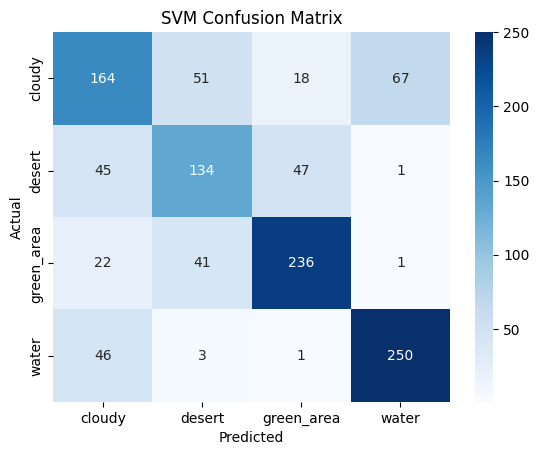

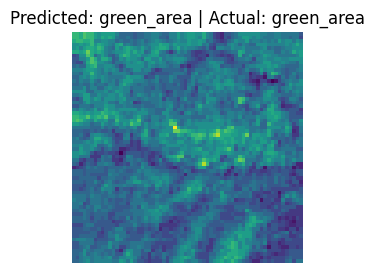

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def svm_classifier(features, images, labels, class_names):
    X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
        features, labels, images, test_size=0.2, random_state=42, stratify=labels
    )

    svm = SVC(kernel='linear')
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("SVM Accuracy:", round(acc * 100, 2), "%")
    print("\nSVM Classification Report:\n", classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("SVM Confusion Matrix")
    plt.show()

    sample_index = 99
    sample_img = img_test[sample_index]
    sample_pred = svm.predict(X_test[sample_index].reshape(1, -1))[0]
    actual_label = y_test[sample_index]

    
    plt.figure(figsize=(3,3))
    plt.imshow(sample_img)
    plt.title(f"Predicted: {class_names[sample_pred]} | Actual: {class_names[actual_label]}")
    plt.axis('off')
    plt.show()

    return svm

svm_model = svm_classifier(hog_features, images, labels, class_names)


Naive Bayes Accuracy: 62.11 %

Naive Bayes Classification Report:
               precision    recall  f1-score   support

      cloudy       0.47      0.30      0.37       300
      desert       0.52      0.63      0.57       227
  green_area       0.76      0.78      0.77       300
       water       0.66      0.77      0.71       300

    accuracy                           0.62      1127
   macro avg       0.60      0.62      0.60      1127
weighted avg       0.61      0.62      0.61      1127



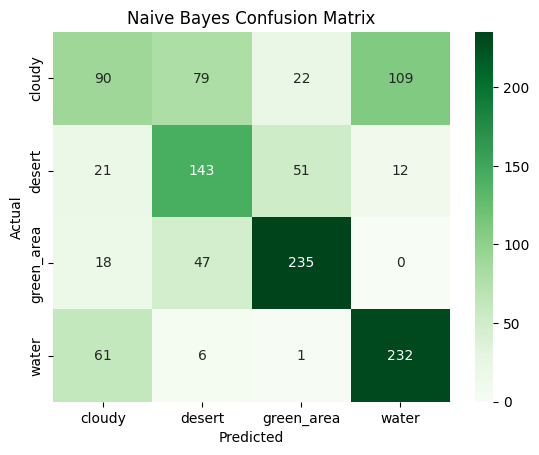

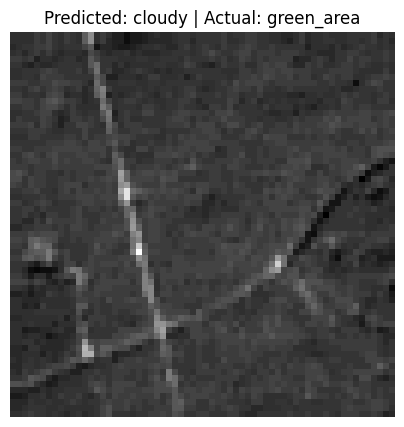

In [22]:
from sklearn.naive_bayes import GaussianNB

def nb_classifier(features, images, labels, class_names):
    X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
        features, labels, images, test_size=0.2, random_state=42, stratify=labels
    )

    nb = GaussianNB()
    nb.fit(X_train, y_train)
    y_pred = nb.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("Naive Bayes Accuracy:", round(acc * 100, 2), "%")
    print("\nNaive Bayes Classification Report:\n", classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Naive Bayes Confusion Matrix")
    plt.show()

    sample_index = 55
    sample_img = img_test[sample_index]
    sample_pred = nb.predict(X_test[sample_index].reshape(1, -1))[0]
    actual_label = y_test[sample_index]

    plt.figure(figsize=(5,5))
    plt.imshow(sample_img, cmap='gray')
    plt.title(f"Predicted: {class_names[sample_pred]} | Actual: {class_names[actual_label]}")
    plt.axis('off')
    plt.show()

    return nb

nb_model = nb_classifier(hog_features, images, labels, class_names)
